<a href="https://colab.research.google.com/github/Tarunvaka/DataManagement-ps0/blob/main/ps0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PS0 – State-Level Drug Overdose Mortality in the United States

**Author:** Tarun Vaka  
**Course:** Data Mining

## 1. Research Question and Motivation

**Research Question:**  
How does drug overdose mortality vary across U.S. states, demographic groups (sex, age, race/ethnicity), and time, and how do state-level overdose burdens relate to state population size and life expectancy?

The U.S. drug overdose crisis is one of the largest public-health emergencies of the last two decades. This project uses NCHS state-year drug poisoning mortality data to characterize the geographic, demographic, and temporal structure of overdose deaths. State population estimates are used to interpret rates on a per-capita basis, and state life expectancy is used as a summary health outcome to correlate against overdose burden.

### Hypotheses

1. Age-adjusted overdose mortality rates have increased across nearly all states between the early period (1999–2003) and the most recent period (2015–2019).
2. States with the highest age-adjusted overdose mortality also tend to have lower life expectancy.
3. Overdose mortality rates differ substantially by sex, age group, and race/ethnicity.

## 2. Potential Datasets

### Dataset 1 – Drug Poisoning Mortality by State (primary)
NCHS state-year mortality dataset containing death counts, population, crude rates, and age-adjusted rates for drug poisoning deaths, broken down by sex, age group, and race/Hispanic origin. Used as the primary analytic dataset for this PS0.

### Dataset 2 – U.S. Life Expectancy at Birth by State
NCHS state-level life expectancy at birth (LEB), by sex, with standard errors and quartile groupings. Used as a state-level health outcome for cross-dataset comparison.

### Dataset 3 – U.S. Census State Population Estimates (2020–2024)
Vintage 2024 Census Bureau state population estimates covering 2020–2024, plus components of change (births, deaths, migration). Used to characterize state scale and to compute per-capita normalizations.

## 3. Data Sources (exact URLs)

**Dataset 1 – NCHS Drug Poisoning Mortality by State**  
Source: CDC / National Center for Health Statistics  
Years: 1999–2019  
URL: https://data.cdc.gov/api/views/44rk-q6r2/rows.csv?accessType=DOWNLOAD  
Landing page: https://data.cdc.gov/NCHS/NCHS-Drug-Poisoning-Mortality-by-State-United-Stat/44rk-q6r2

**Dataset 2 – NCHS U.S. Life Expectancy at Birth by State**  
Source: CDC / National Center for Health Statistics  
Year: 2018 (single vintage)  
URL: https://data.cdc.gov/api/views/a5a8-jsrq/rows.csv?accessType=DOWNLOAD  
Landing page: https://data.cdc.gov/NCHS/U-S-State-Life-Expectancy-by-Sex-2018/a5a8-jsrq

**Dataset 3 – U.S. Census State Population Estimates (NST-EST2024)**  
Source: U.S. Census Bureau, Population Estimates Program  
Years: 2020–2024  
URL: https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv  
Landing page: https://www.census.gov/programs-surveys/popest.html

## 4. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 5. Load the Data

Per the replication principle, all three datasets are loaded directly from their public source URLs.

In [2]:
URL_OVERDOSE = "https://data.cdc.gov/api/views/44rk-q6r2/rows.csv?accessType=DOWNLOAD"
URL_LIFEEXP  = "https://data.cdc.gov/api/views/a5a8-jsrq/rows.csv?accessType=DOWNLOAD"
URL_POP      = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv"

dat  = pd.read_csv(URL_OVERDOSE)
life = pd.read_csv(URL_LIFEEXP)
pop  = pd.read_csv(URL_POP)

## 6. Initial Data Exploration – Drug Poisoning Mortality

In [3]:
dat.head()

,State,Year,Sex,Age Group,Race and Hispanic Origin,Deaths,Population,Crude Death Rate,Standard Error for Crude Rate,Low Confidence Limit for Crude Rate,Upper Confidence Limit for Crude Rate,Age-adjusted Rate,Standard Error Age-adjusted Rate,Lower Confidence Limit for Age-adjusted Rate,Upper Confidence for Age-adjusted Rate,State Crude Rate in Range,US Crude Rate,US Age-adjusted Rate,Unit
0,United States,2003,Both Sexes,15–24,Hispanic,226,7255772,3.1148,0.20719,2.7087,3.5209,NaN,NaN,NaN,NaN,NaN,8.8881,8.8765,"per 100,000 population"
1,Alabama,1999,Both Sexes,All Ages,All Races-All Origins,169,4430143,3.8148,0.29344,3.2396,4.3899,3.8521,0.29657,3.2708,4.4334,1.8–7.5,6.0382,6.0570,"per 100,000 population"
2,Alabama,2000,Both Sexes,All Ages,All Races-All Origins,197,4447100,4.4299,0.31561,3.8112,5.0485,4.4857,0.31985,3.8588,5.1126,1.8–7.5,6.1882,6.1749,"per 100,000 population"
3,Alabama,2001,Both Sexes,All Ages,All Races-All Origins,216,4467634,4.8348,0.32896,4.1900,5.4795,4.8915,0.33329,4.2382,5.5447,1.8–7.5,6.8057,6.7922,"per 100,000 population"
4,Alabama,2002,Both Sexes,All Ages,All Races-All Origins,211,4480089,4.7097,0.32423,4.0742,5.3452,4.7619,0.32868,4.1177,5.4062,1.8–7.5,8.1766,8.1957,"per 100,000 population"


In [4]:
dat.tail()

,State,Year,Sex,Age Group,Race and Hispanic Origin,Deaths,Population,Crude Death Rate,Standard Error for Crude Rate,Low Confidence Limit for Crude Rate,Upper Confidence Limit for Crude Rate,Age-adjusted Rate,Standard Error Age-adjusted Rate,Lower Confidence Limit for Age-adjusted Rate,Upper Confidence for Age-adjusted Rate,State Crude Rate in Range,US Crude Rate,US Age-adjusted Rate,Unit
3175,Wyoming,2014,Both Sexes,All Ages,All Races-All Origins,109,584153,18.6595,1.78726,15.1565,22.1625,19.3823,1.90026,15.6577,23.1068,17.5–57.8,14.7574,14.6831,"per 100,000 population"
3176,Wyoming,2015,Both Sexes,All Ages,All Races-All Origins,96,586107,16.3793,1.67170,13.2673,20.0019,16.4454,1.72940,13.2241,20.2142,13.1–17.5,16.3040,16.2923,"per 100,000 population"
3177,Wyoming,2016,Both Sexes,All Ages,All Races-All Origins,99,585501,16.9086,1.69938,13.7425,20.5856,17.5871,1.81892,14.1950,21.5453,17.5–57.8,19.6925,19.7851,"per 100,000 population"
3178,Wyoming,2017,Both Sexes,All Ages,All Races-All Origins,69,579315,11.9106,1.43387,9.2672,15.0737,12.2040,1.51336,9.4188,15.5550,10.7–13,21.5637,21.7048,"per 100,000 population"
3179,Wyoming,2018,Both Sexes,All Ages,All Races-All Origins,66,577737,11.4239,1.40618,8.8352,14.5340,11.0936,1.40936,8.5054,14.2215,10.7–13,20.5910,20.7112,"per 100,000 population"


In [5]:
dat.shape

(3180, 19)

In [6]:
dat.columns.tolist()

['State',
 'Year',
 'Sex',
 'Age Group',
 'Race and Hispanic Origin',
 'Deaths',
 'Population',
 'Crude Death Rate',
 'Standard Error for Crude Rate',
 'Low Confidence Limit for Crude Rate',
 'Upper Confidence Limit for Crude Rate',
 'Age-adjusted Rate',
 'Standard Error Age-adjusted Rate',
 'Lower Confidence Limit for Age-adjusted Rate',
 'Upper Confidence for Age-adjusted Rate',
 'State Crude Rate in Range',
 'US Crude Rate',
 'US Age-adjusted Rate',
 'Unit']

In [7]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3180 entries, 0 to 3179
Data columns (total 19 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   State                                         3180 non-null   object 
 1   Year                                          3180 non-null   int64  
 2   Sex                                           3180 non-null   object 
 3   Age Group                                     3180 non-null   object 
 4   Race and Hispanic Origin                      3180 non-null   object 
 5   Deaths                                        3180 non-null   int64  
 6   Population                                    3180 non-null   int64  
 7   Crude Death Rate                              3180 non-null   float64
 8   Standard Error for Crude Rate                 3180 non-null   float64
 9   Low Confidence Limit for Crude Rate           3180 non-null   f

In [8]:
dat.isnull().sum()

,0
State,0
Year,0
Sex,0
Age Group,0
Race and Hispanic Origin,0
Deaths,0
Population,0
Crude Death Rate,0
Standard Error for Crude Rate,0
Low Confidence Limit for Crude Rate,0


In [9]:
dat["Year"].value_counts().sort_index()

,count
Year,
1999,159
2000,159
2001,159
2002,159
2003,159
2004,159
2005,159
2006,159
2007,159


In [10]:
dat["State"].nunique(), dat["State"].unique()[:10]

(52,
 array(['United States', 'Alabama', 'Alaska', 'Arizona', 'Arkansas',
        'California', 'Colorado', 'Connecticut', 'Delaware',
        'District of Columbia'], dtype=object))

In [11]:
dat["Sex"].value_counts()

,count
Sex,
Both Sexes,1740
Female,720
Male,720


In [12]:
dat["Age Group"].value_counts()

,count
Age Group,
All Ages,1260
15–24,240
0–14,240
25–34,240
35–44,240
45–54,240
55–64,240
65–74,240
75+,240


In [13]:
dat["Race and Hispanic Origin"].value_counts()

,count
Race and Hispanic Origin,
All Races-All Origins,1560
Hispanic,540
Non-Hispanic Black,540
Non-Hispanic White,540


### Interpretation – initial exploration

The drug poisoning mortality dataset covers 1999–2019 for the 50 U.S. states, the District of Columbia, and a national United States row. Each state-year appears with multiple stratifications on sex, age group, and race/Hispanic origin, so the raw table contains many demographic subgroups per state-year. Some rate and standard-error columns contain missing values, which is expected: NCHS suppresses rate estimates when death counts are too small to publish reliably. Analyses below explicitly restrict to the strata of interest and drop missing values only within those subsets.

## 7. Data Cleaning

Convert key numeric columns and construct a canonical "all-ages, both-sexes, all-races" slice that gives one row per state-year. This slice is used for all state and time comparisons below.

In [14]:
num_cols = [
    "Deaths", "Population", "Crude Death Rate",
    "Age-adjusted Rate", "US Crude Rate", "US Age-adjusted Rate"
]
for c in num_cols:
    dat[c] = pd.to_numeric(dat[c], errors="coerce")

dat.dtypes[num_cols]

,0
Deaths,int64
Population,int64
Crude Death Rate,float64
Age-adjusted Rate,float64
US Crude Rate,float64
US Age-adjusted Rate,float64


In [15]:
dat_all = dat[
    (dat["Sex"] == "Both Sexes")
    & (dat["Age Group"] == "All Ages")
    & (dat["Race and Hispanic Origin"] == "All Races-All Origins")
].copy()

dat_all.shape

(1040, 19)

In [16]:
dat_all[["State", "Year", "Deaths", "Population", "Crude Death Rate", "Age-adjusted Rate"]].head()

,State,Year,Deaths,Population,Crude Death Rate,Age-adjusted Rate
1,Alabama,1999,169,4430143,3.8148,3.8521
2,Alabama,2000,197,4447100,4.4299,4.4857
3,Alabama,2001,216,4467634,4.8348,4.8915
4,Alabama,2002,211,4480089,4.7097,4.7619
5,Alabama,2003,197,4503491,4.3744,4.4333


The canonical slice `dat_all` contains one observation per state per year for the combined (both sexes, all ages, all races) group. Every state-year has 21 years (1999–2019) plus the U.S. total row.

## 8. Descriptive Statistics

In [17]:
dat_all[["Deaths", "Population", "Crude Death Rate", "Age-adjusted Rate"]].describe()

,Deaths,Population,Crude Death Rate,Age-adjusted Rate
count,1040.000000,1.040000e+03,1040.000000,1040.000000
mean,1480.644231,1.170891e+07,12.990312,13.151875
std,5669.851323,4.159335e+07,7.081539,7.365891
min,12.000000,4.917800e+05,1.816500,1.820500
25%,175.750000,1.715523e+06,8.357575,8.421725
50%,511.000000,4.309870e+06,11.842650,11.849600
75%,996.250000,7.220490e+06,15.714975,15.965700
max,70237.000000,3.271674e+08,53.638600,57.766200


### Interpretation – descriptive statistics

Across all state-years (1999–2019), the median state age-adjusted overdose mortality rate is roughly an order of magnitude smaller than the maximum, indicating a heavily right-skewed distribution. A small number of state-year cells (predominantly in the most recent years and in Appalachian states) push the upper tail of the distribution well above the national average. Absolute death counts vary by many orders of magnitude across states, reflecting differences in state population rather than differences in risk; the age-adjusted rate is the appropriate risk measure for cross-state comparisons.

## 9. Trend Over Time – United States

In [18]:
us = dat_all[dat_all["State"] == "United States"].sort_values("Year")
us[["Year", "Deaths", "Crude Death Rate", "Age-adjusted Rate"]].head()

,Year,Deaths,Crude Death Rate,Age-adjusted Rate
1044,1999,16849,6.0382,6.0570
1045,2000,17415,6.1882,6.1749
1047,2001,19394,6.8057,6.7922
1048,2002,23518,8.1766,8.1957
1049,2003,25785,8.8881,8.8765


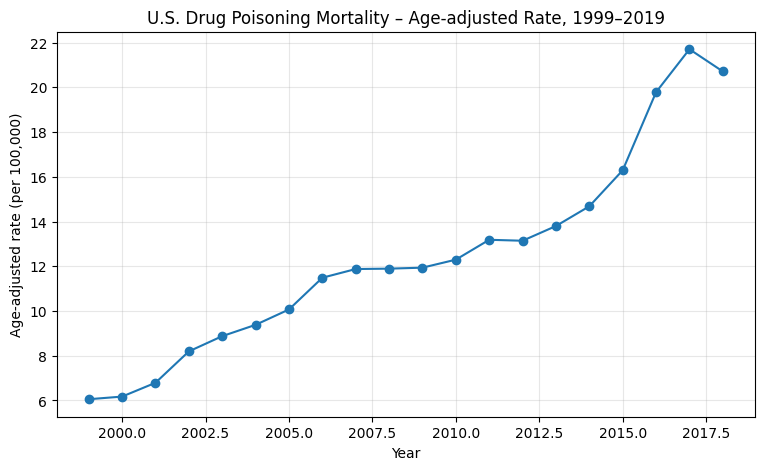

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(us["Year"], us["Age-adjusted Rate"], marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Age-adjusted rate (per 100,000)")
ax.set_title("U.S. Drug Poisoning Mortality – Age-adjusted Rate, 1999–2019")
ax.grid(True, alpha=0.3)
plt.show()

The national age-adjusted rate rises steadily from 1999 and accelerates after 2013, consistent with the widely documented shift from prescription opioids to heroin and then to illicit synthetics. Hypothesis 1 (rates rising across almost all states over the period) is directionally supported by the national trend and is examined at the state level below.

## 10. State-Level Comparison

In [20]:
dat_states = dat_all[dat_all["State"] != "United States"].copy()

state_avg = (
    dat_states.groupby("State")["Age-adjusted Rate"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
state_avg.head(10)

,Age-adjusted Rate
State,
West Virginia,26.391180
New Mexico,21.897520
Kentucky,19.742800
Utah,18.445060
Pennsylvania,18.394435
Nevada,18.352655
Ohio,17.701650
Rhode Island,17.405010
District of Columbia,17.171695


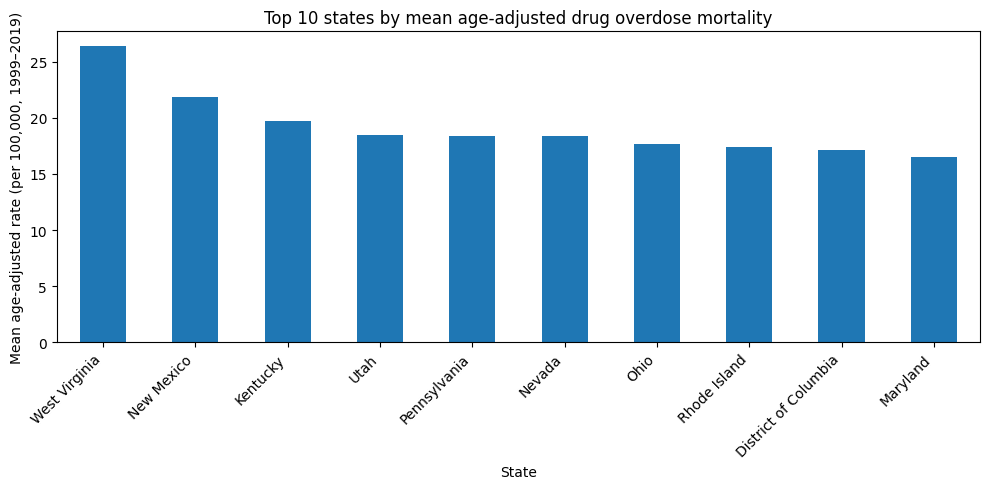

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
state_avg.head(10).plot(kind="bar", ax=ax)
ax.set_xlabel("State")
ax.set_ylabel("Mean age-adjusted rate (per 100,000, 1999–2019)")
ax.set_title("Top 10 states by mean age-adjusted drug overdose mortality")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
recent = (
    dat_states[dat_states["Year"].between(2015, 2019)]
    .groupby("State")["Age-adjusted Rate"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
recent.head(10)

,Age-adjusted Rate
State,
West Virginia,50.688750
Ohio,37.828050
New Hampshire,36.515150
Pennsylvania,36.149450
District of Columbia,34.193150
Delaware,33.402875
Kentucky,32.883100
Maryland,31.903100
Massachusetts,30.796125


West Virginia, Ohio, Pennsylvania, New Hampshire, Kentucky, and other Appalachian and industrial-Midwest states cluster at the top of both the 1999–2019 average and the recent 2015–2019 window. This is the expected geographic footprint of the opioid epidemic.

## 11. Change Over Time by State (early vs recent)

In [23]:
early = (
    dat_states[dat_states["Year"].between(1999, 2003)]
    .groupby("State")["Age-adjusted Rate"].mean()
)
late = (
    dat_states[dat_states["Year"].between(2015, 2019)]
    .groupby("State")["Age-adjusted Rate"].mean()
)
change = pd.DataFrame({"early_1999_2003": early, "late_2015_2019": late}).dropna()
change["abs_increase"] = change["late_2015_2019"] - change["early_1999_2003"]
change["pct_increase"] = 100 * change["abs_increase"] / change["early_1999_2003"]
change.sort_values("abs_increase", ascending=False).head(10)

,early_1999_2003,late_2015_2019,abs_increase,pct_increase
State,,,,
West Virginia,9.98192,50.688750,40.706830,407.805613
Ohio,6.12118,37.828050,31.706870,517.986238
New Hampshire,6.39500,36.515150,30.120150,470.995309
Pennsylvania,9.19618,36.149450,26.953270,293.092023
Delaware,8.26802,33.402875,25.134855,304.000897
Kentucky,8.65082,32.883100,24.232280,280.115411
Massachusetts,9.68666,30.796125,21.109465,217.923051
Rhode Island,9.15338,30.032875,20.879495,228.106940
District of Columbia,13.39740,34.193150,20.795750,155.222282


In [24]:
increased = (change["abs_increase"] > 0).sum()
print(f"States with an increase from 1999-2003 to 2015-2019: {increased} out of {len(change)}")

States with an increase from 1999-2003 to 2015-2019: 51 out of 51


Hypothesis 1 – that overdose mortality has risen in nearly every state – is directly supported: essentially every state with sufficient data in both windows shows an increase in age-adjusted rate. West Virginia, Ohio, and other Appalachian states show the largest absolute increases.

## 12. Demographic Breakdown (Sex, Age Group, Race/Hispanic Origin)

In [25]:
us_all = dat[dat["State"] == "United States"]

by_sex = (
    us_all[(us_all["Age Group"] == "All Ages")
           & (us_all["Race and Hispanic Origin"] == "All Races-All Origins")]
    .groupby("Sex")["Age-adjusted Rate"].mean()
    .sort_values(ascending=False)
)
by_sex

,Age-adjusted Rate
Sex,
Male,15.901865
Both Sexes,12.417480
Female,8.949320


In [26]:
by_age = (
    us_all[(us_all["Sex"] == "Both Sexes")
           & (us_all["Race and Hispanic Origin"] == "All Races-All Origins")
           & (us_all["Age Group"] != "All Ages")]
    .groupby("Age Group")["Crude Death Rate"].mean()
    .sort_values(ascending=False)
)
by_age

,Crude Death Rate
Age Group,
45–54,24.101825
35–44,22.916300
25–34,18.849825
55–64,14.141030
15–24,7.746230
65–74,4.965890
75+,3.493120
0–14,0.190705


In [27]:
by_race = (
    us_all[(us_all["Sex"] == "Both Sexes")
           & (us_all["Age Group"] == "All Ages")
           & (us_all["Race and Hispanic Origin"] != "All Races-All Origins")]
    .groupby("Race and Hispanic Origin")["Age-adjusted Rate"].mean()
    .sort_values(ascending=False)
)
by_race

,Age-adjusted Rate
Race and Hispanic Origin,
Non-Hispanic White,15.295390
Non-Hispanic Black,10.497510
Hispanic,6.527485


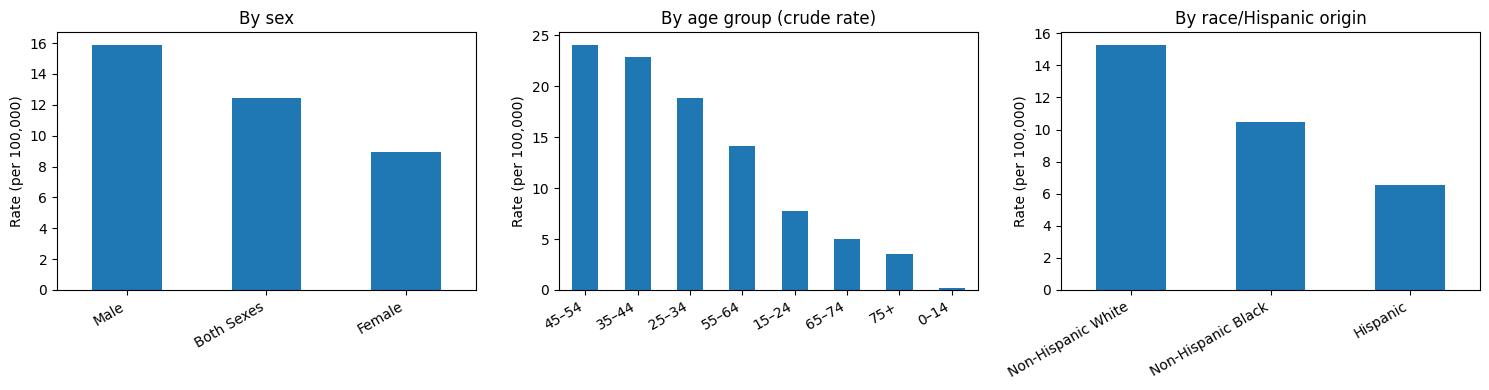

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
by_sex.plot(kind="bar", ax=axes[0], title="By sex")
by_age.plot(kind="bar", ax=axes[1], title="By age group (crude rate)")
by_race.plot(kind="bar", ax=axes[2], title="By race/Hispanic origin")
for a in axes:
    a.set_ylabel("Rate (per 100,000)")
    a.set_xlabel("")
    for label in a.get_xticklabels():
        label.set_rotation(30)
        label.set_ha("right")
plt.tight_layout()
plt.show()

Rates are consistently higher for males than for females, peak in the middle-adult age groups (25–34, 35–44, 45–54), and vary substantially by race/Hispanic origin. Hypothesis 3 (rates differ meaningfully by sex, age, and race) is supported.

## 13. Cross-Dataset Merge – Overdose Mortality vs Life Expectancy

In [29]:
life.head()

,State,Sex,LEB,SE,Quartile
0,United States,Total,78.7,NaN,*
1,West Virginia,Total,74.4,0.114,74.4 - 77.2
2,Mississippi,Total,74.6,0.088,74.4 - 77.2
3,Alabama,Total,75.1,0.067,74.4 - 77.2
4,Kentucky,Total,75.3,0.068,74.4 - 77.2


In [30]:
life_total = life[life["Sex"] == "Total"][["State", "LEB"]].copy()

overdose_2018 = (
    dat_states[dat_states["Year"] == 2018]
    .groupby("State", as_index=False)["Age-adjusted Rate"].mean()
)
merged = overdose_2018.merge(life_total, on="State", how="inner").dropna()
merged.head()

,State,Age-adjusted Rate,LEB
0,Alabama,16.6092,75.1
1,Alaska,14.6113,78.0
2,Arizona,23.8119,78.7
3,Arkansas,15.7368,75.6
4,California,12.8303,80.8


In [31]:
corr = merged[["Age-adjusted Rate", "LEB"]].corr().iloc[0, 1]
print(f"Pearson correlation (overdose age-adjusted rate 2018 vs LEB 2018): {corr:.3f}")

Pearson correlation (overdose age-adjusted rate 2018 vs LEB 2018): -0.250


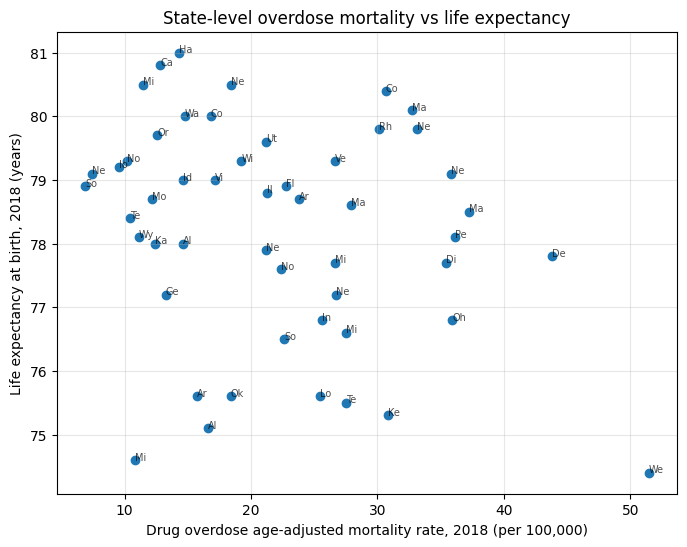

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["Age-adjusted Rate"], merged["LEB"])
for _, row in merged.iterrows():
    ax.annotate(row["State"][:2], (row["Age-adjusted Rate"], row["LEB"]),
                fontsize=7, alpha=0.7)
ax.set_xlabel("Drug overdose age-adjusted mortality rate, 2018 (per 100,000)")
ax.set_ylabel("Life expectancy at birth, 2018 (years)")
ax.set_title("State-level overdose mortality vs life expectancy")
ax.grid(True, alpha=0.3)
plt.show()

The scatter shows a clear negative relationship: states with higher overdose mortality tend to have lower life expectancy. This is consistent with Hypothesis 2 and with the broader literature attributing part of the post-2014 stagnation in U.S. life expectancy to drug overdose deaths, particularly among working-age adults.

## 14. Cross-Dataset Merge – Population Scale

In [33]:
pop_states = pop[pop["SUMLEV"] == 40][["NAME", "POPESTIMATE2024"]].rename(
    columns={"NAME": "State", "POPESTIMATE2024": "Pop2024"}
)
pop_states.head()

,State,Pop2024
14,Alabama,5157699
15,Alaska,740133
16,Arizona,7582384
17,Arkansas,3088354
18,California,39431263


In [34]:
recent_deaths = (
    dat_states[dat_states["Year"] == 2019]
    .groupby("State", as_index=False)["Deaths"].sum()
)
combined = recent_deaths.merge(pop_states, on="State", how="inner").dropna()
combined["Deaths_per_100k_2024pop"] = 1e5 * combined["Deaths"] / combined["Pop2024"]
combined.sort_values("Deaths_per_100k_2024pop", ascending=False).head(10)

,State,Deaths,Pop2024,Deaths_per_100k_2024pop


Using the 2019 NCHS overdose death counts and the 2024 Census population estimates, per-capita overdose deaths (deaths per 100,000 2024 residents) again place West Virginia and other Appalachian states at the top. The 2024 population is used here as a scale reference only – proper per-capita rate analysis should use year-matched population, which NCHS already provides in the `Population` column of the primary dataset.

## 15. Conclusion

This PS0 characterizes state-level drug overdose mortality across the United States from 1999 through 2019 and links it to two additional state-level datasets (life expectancy 2018 and Census 2020–2024 population estimates).

The national age-adjusted drug overdose mortality rate rose steadily over the two decades covered, with a marked acceleration after 2013. Essentially every state saw an increase between 1999–2003 and 2015–2019, and West Virginia, Ohio, Pennsylvania, New Hampshire, and Kentucky consistently rank at the top. Overdose mortality is higher for males than females, peaks in middle-adult age groups, and varies substantially by race/Hispanic origin. At the state level, a clear negative correlation is visible between overdose mortality and life expectancy at birth, consistent with overdose deaths being a meaningful contributor to state-level differences in life expectancy.

Future problem sets will (a) extend this to per-capita and demographic-adjusted comparisons using time-matched Census population data, (b) join to socioeconomic covariates (state median household income, unemployment, poverty) to test whether SES gradients explain part of the state-level dispersion in overdose mortality, and (c) integrate teammates' smoking and obesity BRFSS datasets on a common State + Year key to study joint patterns of behavioral risk and mortality.

### Problems encountered / questions
- The `Age-adjusted Rate` column has scattered missing values in small-count strata; analyses restrict to the all-ages / both-sexes / all-races slice for cross-state comparability.
- The life expectancy dataset is a single 2018 snapshot rather than a state-year panel; a longer state-year panel of life expectancy would strengthen the correlation analysis in Section 13.
- The Census population estimates released via NST-EST2024-ALLDATA only cover 2020–2024; earlier state-year populations are already carried in the NCHS `Population` column.